In [1]:
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [2]:
import os

print("MyDrive exists:", os.path.exists("/content/drive/MyDrive"))

print("\nMyDrive contents:")
for item in os.listdir("/content/drive/MyDrive"):
    print(item)

MyDrive exists: True

MyDrive contents:
Salma_Elshehy_Computer_and_Communication_Engineering.pdf
Task 1.2
Flickr8k_features
Flickr8k_checkpoints
Task1.2.ipynb


In [3]:
os.listdir("/content/drive/MyDrive")

['Salma_Elshehy_Computer_and_Communication_Engineering.pdf',
 'Task 1.2',
 'Flickr8k_features',
 'Flickr8k_checkpoints',
 'Task1.2.ipynb']

In [4]:
from pathlib import Path

TASK_DIR = Path("/content/drive/MyDrive/Task 1.2")

print("Task 1.2 exists:", TASK_DIR.exists())
print("\nContents:")

for item in TASK_DIR.iterdir():
    print(
        "📁" if item.is_dir() else "📄",
        item.name
    )

Task 1.2 exists: True

Contents:
📄 Task1.2.ipynb
📁 captions.txt
📁 Images


In [7]:
from pathlib import Path

TASK_DIR = Path("/content/drive/MyDrive/Task 1.2")

CAPTIONS_FOLDER = TASK_DIR / "captions.txt"

print("Captions folder exists:", CAPTIONS_FOLDER.exists())
print("Is folder:", CAPTIONS_FOLDER.is_dir())

print("\nInside captions.txt:")

for item in CAPTIONS_FOLDER.iterdir():
    print(
        "📁" if item.is_dir() else "📄",
        repr(item.name)
    )

Captions folder exists: True
Is folder: True

Inside captions.txt:
📄 'captions.txt'


In [8]:
CAPTIONS_PATH = CAPTIONS_FOLDER / "captions.txt"

print("\nCAPTIONS_PATH:")
print(CAPTIONS_PATH)

print("Exists:", CAPTIONS_PATH.exists())


CAPTIONS_PATH:
/content/drive/MyDrive/Task 1.2/captions.txt/captions.txt
Exists: True


In [9]:
CAPTIONS_PATH = (
    TASK_DIR /
    "captions.txt" /
    "captions.txt"
)

print("CAPTIONS_PATH:", CAPTIONS_PATH)
print("Exists:", CAPTIONS_PATH.exists())

CAPTIONS_PATH: /content/drive/MyDrive/Task 1.2/captions.txt/captions.txt
Exists: True


In [11]:
# ============================================
# Load Captions Data
# ============================================

import pandas as pd

captions_df = pd.read_csv(CAPTIONS_PATH)

print("Dataset shape:", captions_df.shape)

print("\nColumns:")
print(captions_df.columns.tolist())

print("\nFirst 10 rows:")
display(captions_df.head(10))

Dataset shape: (40455, 2)

Columns:
['image', 'caption']

First 10 rows:


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...
5,1001773457_577c3a7d70.jpg,A black dog and a spotted dog are fighting
6,1001773457_577c3a7d70.jpg,A black dog and a tri-colored dog playing with...
7,1001773457_577c3a7d70.jpg,A black dog and a white dog with brown spots a...
8,1001773457_577c3a7d70.jpg,Two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,Two dogs on pavement moving toward each other .


In [12]:
caption_counts = captions_df.groupby("image")["caption"].count()

print("Number of unique images:", caption_counts.size)

print("\nCaption count distribution:")
print(caption_counts.value_counts().sort_index())

print("\nMinimum captions per image:", caption_counts.min())
print("Maximum captions per image:", caption_counts.max())

Number of unique images: 8091

Caption count distribution:
caption
5    8091
Name: count, dtype: int64

Minimum captions per image: 5
Maximum captions per image: 5


In [14]:
# ============================================
# Define Dataset Paths
# ============================================

from pathlib import Path

TASK_DIR = Path(
    "/content/drive/MyDrive/Task 1.2"
)

IMAGES_DIR = TASK_DIR / "Images"

CAPTIONS_PATH = (
    TASK_DIR /
    "captions.txt" /
    "captions.txt"
)

print("Task directory:", TASK_DIR)
print("Task exists:", TASK_DIR.exists())

print("\nImages directory:", IMAGES_DIR)
print("Images exists:", IMAGES_DIR.exists())

print("\nCaptions path:", CAPTIONS_PATH)
print("Captions exists:", CAPTIONS_PATH.exists())

Task directory: /content/drive/MyDrive/Task 1.2
Task exists: True

Images directory: /content/drive/MyDrive/Task 1.2/Images
Images exists: True

Captions path: /content/drive/MyDrive/Task 1.2/captions.txt/captions.txt
Captions exists: True


In [15]:
# ============================================
# Check Image-Caption Matching
# ============================================

image_files = list(
    IMAGES_DIR.glob("*.jpg")
)

print(
    "Number of JPG images:",
    len(image_files)
)

caption_images = set(
    captions_df["image"]
)

actual_images = {
    img.name
    for img in image_files
}

missing_images = (
    caption_images - actual_images
)

extra_images = (
    actual_images - caption_images
)

print(
    "Images in captions:",
    len(caption_images)
)

print(
    "Images on disk:",
    len(actual_images)
)

print(
    "Missing images:",
    len(missing_images)
)

print(
    "Extra images:",
    len(extra_images)
)

Number of JPG images: 8091
Images in captions: 8091
Images on disk: 8091
Missing images: 0
Extra images: 0


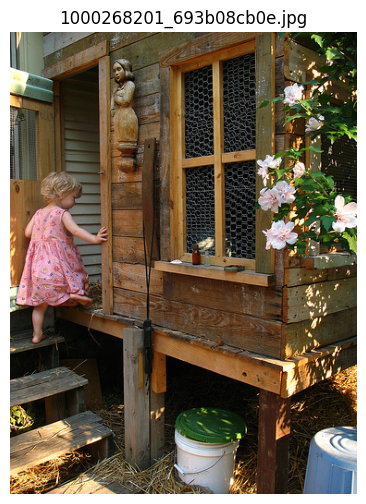

Reference Captions:

1. A child in a pink dress is climbing up a set of stairs in an entry way .
2. A girl going into a wooden building .
3. A little girl climbing into a wooden playhouse .
4. A little girl climbing the stairs to her playhouse .
5. A little girl in a pink dress going into a wooden cabin .


In [16]:
import matplotlib.pyplot as plt
from PIL import Image

sample_image = captions_df["image"].iloc[0]
image_path = IMAGES_DIR / sample_image

image = Image.open(image_path)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")
plt.title(sample_image)
plt.show()

print("Reference Captions:\n")

for i, caption in enumerate(
    captions_df[captions_df["image"] == sample_image]["caption"],
    1
):
    print(f"{i}. {caption}")

In [17]:
captions_df["caption_length"] = (
    captions_df["caption"]
    .str.split()
    .str.len()
)

print("Caption statistics:")
print(captions_df["caption_length"].describe())

Caption statistics:
count    40455.000000
mean        11.782598
std          3.885152
min          1.000000
25%          9.000000
50%         11.000000
75%         14.000000
max         38.000000
Name: caption_length, dtype: float64


In [18]:
from collections import Counter

word_counts = Counter(
    word.lower()
    for caption in captions_df["caption"]
    for word in caption.split()
)

print("Total unique words:", len(word_counts))

print("\nMost common 20 words:")

for word, count in word_counts.most_common(20):
    print(f"{word:15s} {count}")

Total unique words: 8918

Most common 20 words:
a               62986
.               36577
in              18974
the             18418
on              10743
is              9345
and             8851
dog             8136
with            7765
man             7265
of              6713
two             5638
white           3940
black           3832
boy             3581
are             3504
woman           3402
girl            3328
,               3232
to              3173


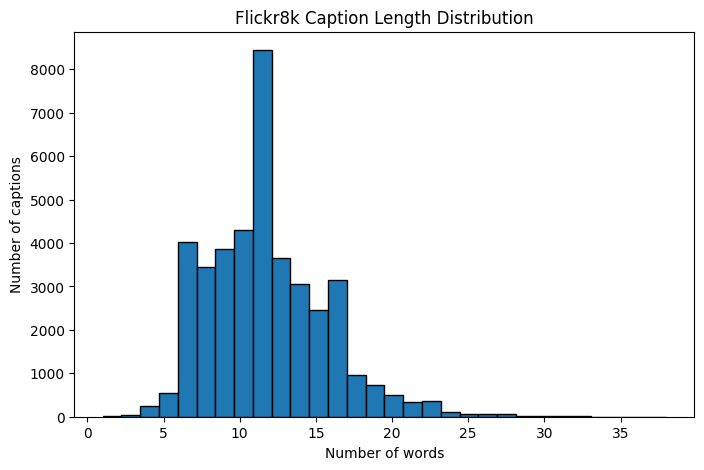

In [19]:
plt.figure(figsize=(8, 5))

plt.hist(
    captions_df["caption_length"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Number of words")
plt.ylabel("Number of captions")
plt.title("Flickr8k Caption Length Distribution")

plt.show()

In [20]:
from sklearn.model_selection import train_test_split
import numpy as np

# Get unique image names as a normal NumPy array
unique_images = np.array(
    captions_df["image"].unique().tolist()
)

print("Total unique images:", len(unique_images))

# 80% Train, 10% Validation, 10% Test
train_images, temp_images = train_test_split(
    unique_images,
    test_size=0.20,
    random_state=42
)

val_images, test_images = train_test_split(
    temp_images,
    test_size=0.50,
    random_state=42
)

print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

Total unique images: 8091
Train images: 6472
Validation images: 809
Test images: 810


In [21]:
train_df = captions_df[
    captions_df["image"].isin(train_images)
].copy()

val_df = captions_df[
    captions_df["image"].isin(val_images)
].copy()

test_df = captions_df[
    captions_df["image"].isin(test_images)
].copy()

print("Train captions:", len(train_df))
print("Validation captions:", len(val_df))
print("Test captions:", len(test_df))

Train captions: 32360
Validation captions: 4045
Test captions: 4050


In [22]:
train_set = set(train_images)
val_set = set(val_images)
test_set = set(test_images)

print("Train ∩ Validation:", len(train_set & val_set))
print("Train ∩ Test:", len(train_set & test_set))
print("Validation ∩ Test:", len(val_set & test_set))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [23]:
import re

def clean_caption(text):
    text = str(text).lower()

    # Remove punctuation
    text = re.sub(r"[^a-z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text


# Apply cleaning
for df_split in [train_df, val_df, test_df]:
    df_split["clean_caption"] = df_split["caption"].apply(clean_caption)

# Show examples
display(
    train_df[["caption", "clean_caption"]].head(10)
)

,caption,clean_caption
0,A child in a pink dress is climbing up a set o...,a child in a pink dress is climbing up a set o...
1,A girl going into a wooden building .,a girl going into a wooden building
2,A little girl climbing into a wooden playhouse .,a little girl climbing into a wooden playhouse
3,A little girl climbing the stairs to her playh...,a little girl climbing the stairs to her playh...
4,A little girl in a pink dress going into a woo...,a little girl in a pink dress going into a woo...
5,A black dog and a spotted dog are fighting,a black dog and a spotted dog are fighting
6,A black dog and a tri-colored dog playing with...,a black dog and a tri colored dog playing with...
7,A black dog and a white dog with brown spots a...,a black dog and a white dog with brown spots a...
8,Two dogs of different breeds looking at each o...,two dogs of different breeds looking at each o...
9,Two dogs on pavement moving toward each other .,two dogs on pavement moving toward each other


In [24]:
# ============================================
# 2. Add special tokens
# ============================================

def add_special_tokens(text):
    return f"<start> {text} <end>"


train_df["processed_caption"] = train_df["clean_caption"].apply(
    add_special_tokens
)

val_df["processed_caption"] = val_df["clean_caption"].apply(
    add_special_tokens
)

test_df["processed_caption"] = test_df["clean_caption"].apply(
    add_special_tokens
)

display(
    train_df[["image", "caption", "processed_caption"]].head()
)

,image,caption,processed_caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...,<start> a child in a pink dress is climbing up...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .,<start> a girl going into a wooden building <end>
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .,<start> a little girl climbing into a wooden p...
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...,<start> a little girl climbing the stairs to h...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...,<start> a little girl in a pink dress going in...


In [25]:
from collections import Counter

word_counter = Counter()

for caption in train_df["clean_caption"]:
    word_counter.update(caption.split())

print(
    "Total unique words before filtering:",
    len(word_counter)
)

print("\nMost common 20 words:")

for word, count in word_counter.most_common(20):
    print(f"{word:15s} {count}")

Total unique words before filtering: 7688

Most common 20 words:
a               50190
in              15208
the             14758
on              8542
is              7365
and             7140
dog             6394
with            6266
man             5895
of              5413
two             4521
white           3117
black           3091
boy             2902
are             2844
woman           2782
girl            2625
to              2521
wearing         2484
at              2292


In [26]:
MIN_WORD_FREQ = 2

vocab_words = [
    word
    for word, count in word_counter.items()
    if count >= MIN_WORD_FREQ
]

print("Vocabulary words with frequency >= 2:", len(vocab_words))

Vocabulary words with frequency >= 2: 4649


In [27]:
SPECIAL_TOKENS = [
    "<pad>",
    "<unk>",
    "<start>",
    "<end>"
]

word2idx = {
    token: idx
    for idx, token in enumerate(SPECIAL_TOKENS)
}

for word in sorted(vocab_words):
    if word not in word2idx:
        word2idx[word] = len(word2idx)

idx2word = {
    idx: word
    for word, idx in word2idx.items()
}

print("Final vocabulary size:", len(word2idx))

print("\nSpecial tokens:")
for token in SPECIAL_TOKENS:
    print(token, "->", word2idx[token])

Final vocabulary size: 4653

Special tokens:
<pad> -> 0
<unk> -> 1
<start> -> 2
<end> -> 3


In [28]:
# ============================================
# 6. Convert caption to token IDs
# ============================================

def caption_to_ids(caption):
    tokens = caption.split()

    return [
        word2idx.get(token, word2idx["<unk>"])
        for token in tokens
    ]


example_caption = train_df["processed_caption"].iloc[0]

print("Caption:")
print(example_caption)

print("\nTokens:")
print(example_caption.split())

print("\nIDs:")
print(caption_to_ids(example_caption))

Caption:
<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>

Tokens:
['<start>', 'a', 'child', 'in', 'a', 'pink', 'dress', 'is', 'climbing', 'up', 'a', 'set', 'of', 'stairs', 'in', 'an', 'entry', 'way', '<end>']

IDs:
[2, 4, 740, 1970, 4, 2881, 1181, 2024, 786, 4378, 4, 3457, 2614, 3841, 1970, 86, 1, 4508, 3]


In [29]:
# 7. Imports for Image Feature Extraction

import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [30]:
# 8. Load Pretrained ResNet-50

weights = models.ResNet50_Weights.DEFAULT

resnet = models.resnet50(weights=weights)

# Remove the final classification layer
resnet = nn.Sequential(*list(resnet.children())[:-1])

resnet = resnet.to(device)
resnet.eval()

print(resnet)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 121MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [31]:
# 9. Image Preprocessing

image_transform = weights.transforms()

print(image_transform)

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [32]:
# 10. Image Dataset

class ImageFeatureDataset(Dataset):

    def __init__(self, image_names, images_dir, transform):
        self.image_names = list(image_names)
        self.images_dir = Path(images_dir)
        self.transform = transform

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):

        image_name = self.image_names[idx]

        image_path = self.images_dir / image_name

        image = Image.open(image_path).convert("RGB")

        image = self.transform(image)

        return image, image_name

In [33]:
# 11. Feature Cache Directory

FEATURES_DIR = Path("/content/drive/MyDrive/Flickr8k_features")

FEATURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Features will be saved to:")
print(FEATURES_DIR)

Features will be saved to:
/content/drive/MyDrive/Flickr8k_features


In [34]:
# ============================================
# 12. Prepare Unique Images + DataLoader
# ============================================

import numpy as np

# Get all unique image names from the dataset
unique_images = np.array(
    captions_df["image"].unique().tolist()
)

print("Total unique images:", len(unique_images))

# Create Dataset
feature_dataset = ImageFeatureDataset(
    unique_images,
    IMAGES_DIR,
    image_transform
)

# DataLoader
BATCH_SIZE = 64

feature_loader = DataLoader(
    feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Number of images:", len(feature_dataset))
print("Number of batches:", len(feature_loader))

Total unique images: 8091
Number of images: 8091
Number of batches: 127


In [35]:
# 13. Extract Image Features using ResNet-50

image_features = {}

with torch.no_grad():

    for images, image_names in tqdm(
        feature_loader,
        desc="Extracting image features"
    ):
        images = images.to(device)

        # Extract features
        features = resnet(images)

        # [batch_size, 2048, 1, 1]
        features = features.squeeze(-1).squeeze(-1)

        # Move features to CPU
        features = features.cpu()

        for image_name, feature in zip(image_names, features):
            image_features[image_name] = feature

print("\nFeature extraction completed!")
print("Number of extracted images:", len(image_features))

sample_name = next(iter(image_features))

print("Sample image:", sample_name)
print("Feature shape:", image_features[sample_name].shape)

Extracting image features:   0%|          | 0/127 [00:00<?, ?it/s]


Feature extraction completed!
Number of extracted images: 8091
Sample image: 1000268201_693b08cb0e.jpg
Feature shape: torch.Size([2048])


In [36]:
# ============================================
# 14. Save Extracted Image Features
# ============================================

FEATURES_DIR = Path("/content/drive/MyDrive/Flickr8k_features")
FEATURES_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = FEATURES_DIR / "resnet50_features.pt"

torch.save(
    image_features,
    FEATURES_PATH
)

print("Features saved successfully!")
print("Path:", FEATURES_PATH)

print(
    "File size:",
    round(FEATURES_PATH.stat().st_size / (1024**2), 2),
    "MB"
)

Features saved successfully!
Path: /content/drive/MyDrive/Flickr8k_features/resnet50_features.pt
File size: 65.24 MB


In [37]:
# ============================================
# 15. Verify Saved Features
# ============================================

loaded_features = torch.load(
    FEATURES_PATH,
    map_location="cpu",
    weights_only=False
)

print("Loaded features:", len(loaded_features))

sample_name = next(iter(loaded_features))

print("Sample image:", sample_name)
print("Feature shape:", loaded_features[sample_name].shape)

Loaded features: 8091
Sample image: 1000268201_693b08cb0e.jpg
Feature shape: torch.Size([2048])


In [38]:
# ============================================
# 16. Caption Length Analysis
# ============================================

MAX_LEN = max(
    len(caption.split())
    for caption in train_df["processed_caption"]
)

print("Maximum caption length:", MAX_LEN)

Maximum caption length: 38


In [39]:
# ============================================
# 17. Convert Captions to IDs and Pad
# ============================================

from torch.nn.utils.rnn import pad_sequence

PAD_IDX = word2idx["<pad>"]
UNK_IDX = word2idx["<unk>"]
START_IDX = word2idx["<start>"]
END_IDX = word2idx["<end>"]

def caption_to_ids(caption):
    tokens = caption.split()

    return [
        word2idx.get(token, UNK_IDX)
        for token in tokens
    ]


def pad_caption(caption):
    ids = caption_to_ids(caption)

    # Truncate if longer than MAX_LEN
    ids = ids[:MAX_LEN]

    # Pad
    ids += [PAD_IDX] * (MAX_LEN - len(ids))

    return ids

In [40]:
example = train_df["processed_caption"].iloc[0]

ids = pad_caption(example)

print("Caption:")
print(example)

print("\nNumber of IDs:", len(ids))

print("\nFirst IDs:")
print(ids[:20])

Caption:
<start> a child in a pink dress is climbing up a set of stairs in an entry way <end>

Number of IDs: 38

First IDs:
[2, 4, 740, 1970, 4, 2881, 1181, 2024, 786, 4378, 4, 3457, 2614, 3841, 1970, 86, 1, 4508, 3, 0]


In [41]:
# ============================================
# 18. Image Caption Dataset
# ============================================

class CaptionDataset(Dataset):

    def __init__(self, dataframe, image_features, word2idx, max_len):
        self.df = dataframe.reset_index(drop=True)
        self.image_features = image_features
        self.word2idx = word2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_name = row["image"]
        caption = row["processed_caption"]

        # Image feature
        feature = self.image_features[image_name]

        # Caption → IDs
        tokens = caption.split()

        caption_ids = [
            self.word2idx.get(token, self.word2idx["<unk>"])
            for token in tokens
        ]

        # Truncate
        caption_ids = caption_ids[:self.max_len]

        # Padding
        caption_ids += [
            self.word2idx["<pad>"]
        ] * (self.max_len - len(caption_ids))

        caption_ids = torch.tensor(
            caption_ids,
            dtype=torch.long
        )

        return feature, caption_ids

In [42]:
# ============================================
# 19. Create DataLoaders
# ============================================

train_dataset = CaptionDataset(
    train_df,
    loaded_features,
    word2idx,
    MAX_LEN
)

val_dataset = CaptionDataset(
    val_df,
    loaded_features,
    word2idx,
    MAX_LEN
)

test_dataset = CaptionDataset(
    test_df,
    loaded_features,
    word2idx,
    MAX_LEN
)

CAPTION_BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=CAPTION_BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CAPTION_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CAPTION_BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=False
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 32360
Validation samples: 4045
Test samples: 4050


In [43]:
# ============================================
# 20. Test DataLoader
# ============================================

features, captions = next(iter(train_loader))

print("Features shape:", features.shape)
print("Captions shape:", captions.shape)

Features shape: torch.Size([128, 2048])
Captions shape: torch.Size([128, 38])


In [44]:
# ============================================
# 21. Caption Generator Model
# ============================================

import torch
import torch.nn as nn


class ImageCaptioningModel(nn.Module):

    def __init__(
        self,
        feature_dim,
        vocab_size,
        embed_dim=256,
        hidden_dim=512,
        num_layers=1,
        dropout=0.3
    ):
        super().__init__()

        # Image feature projection
        self.feature_projection = nn.Linear(
            feature_dim,
            embed_dim
        )

        # Word embedding
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=PAD_IDX
        )

        # LSTM
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0 if num_layers == 1 else dropout
        )

        # Output layer
        self.fc = nn.Linear(
            hidden_dim,
            vocab_size
        )

        self.dropout = nn.Dropout(dropout)

        # Initialize hidden state from image
        self.init_h = nn.Linear(
            feature_dim,
            hidden_dim
        )

        self.init_c = nn.Linear(
            feature_dim,
            hidden_dim
        )

    def forward(self, features, captions):

        # --------------------------------
        # Image features
        # --------------------------------

        # features:
        # [B, 2048]

        h = self.init_h(features)
        c = self.init_c(features)

        # [B, hidden_dim] → [1, B, hidden_dim]

        h = h.unsqueeze(0)
        c = c.unsqueeze(0)

        # --------------------------------
        # Caption embeddings
        # --------------------------------

        # Remove <end> token
        inputs = captions[:, :-1]

        embeddings = self.embedding(inputs)

        embeddings = self.dropout(embeddings)

        # --------------------------------
        # LSTM
        # --------------------------------

        outputs, _ = self.lstm(
            embeddings,
            (h, c)
        )

        # --------------------------------
        # Vocabulary prediction
        # --------------------------------

        outputs = self.fc(outputs)

        return outputs

In [45]:
# ============================================
# 22. Initialize Model
# ============================================

VOCAB_SIZE = len(word2idx)

model = ImageCaptioningModel(
    feature_dim=2048,
    vocab_size=VOCAB_SIZE,
    embed_dim=256,
    hidden_dim=512,
    num_layers=1,
    dropout=0.3
)

model = model.to(device)

print(model)

ImageCaptioningModel(
  (feature_projection): Linear(in_features=2048, out_features=256, bias=True)
  (embedding): Embedding(4653, 256, padding_idx=0)
  (lstm): LSTM(256, 512, batch_first=True)
  (fc): Linear(in_features=512, out_features=4653, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (init_h): Linear(in_features=2048, out_features=512, bias=True)
  (init_c): Linear(in_features=2048, out_features=512, bias=True)
)


In [46]:
# ============================================
# 23. Test Forward Pass
# ============================================

features, captions = next(iter(train_loader))

features = features.to(device)
captions = captions.to(device)

with torch.no_grad():
    outputs = model(features, captions)

print("Features:", features.shape)
print("Captions:", captions.shape)
print("Model output:", outputs.shape)

Features: torch.Size([128, 2048])
Captions: torch.Size([128, 38])
Model output: torch.Size([128, 37, 4653])


In [47]:
# ============================================
# 24. Loss Function & Optimizer
# ============================================

criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_IDX
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Loss:", criterion)
print("Initial learning rate:", optimizer.param_groups[0]["lr"])

Loss: CrossEntropyLoss()
Initial learning rate: 0.001


In [48]:
# ============================================
# 25. Training & Validation
# ============================================

import time
from pathlib import Path

NUM_EPOCHS = 10
PATIENCE = 3

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/Flickr8k_checkpoints"
)
CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = CHECKPOINT_DIR / "best_caption_model.pth"


def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss = 0

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for features, captions in progress:

        features = features.to(device)
        captions = captions.to(device)

        # Forward pass
        outputs = model(
            features,
            captions
        )

        # Target = caption shifted by one token
        targets = captions[:, 1:]

        # Reshape
        outputs = outputs.reshape(
            -1,
            outputs.size(-1)
        )

        targets = targets.reshape(-1)

        # Loss
        loss = criterion(
            outputs,
            targets
        )

        # Backpropagation
        optimizer.zero_grad()

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        total_loss += loss.item()

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return total_loss / len(loader)


def validate_one_epoch(model, loader, criterion, device):

    model.eval()

    total_loss = 0

    with torch.no_grad():

        progress = tqdm(
            loader,
            desc="Validation",
            leave=False
        )

        for features, captions in progress:

            features = features.to(device)
            captions = captions.to(device)

            outputs = model(
                features,
                captions
            )

            targets = captions[:, 1:]

            outputs = outputs.reshape(
                -1,
                outputs.size(-1)
            )

            targets = targets.reshape(-1)

            loss = criterion(
                outputs,
                targets
            )

            total_loss += loss.item()

            progress.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    return total_loss / len(loader)

In [49]:
# ============================================
# Reload Saved Image Features
# ============================================

from pathlib import Path
import torch

FEATURES_PATH = Path(
    "/content/drive/MyDrive/Flickr8k_features/resnet50_features.pt"
)

loaded_features = torch.load(
    FEATURES_PATH,
    map_location="cpu",
    weights_only=False
)

print("Loaded features:", len(loaded_features))

Loaded features: 8091


In [50]:
# ============================================
# Check Current Training Setup
# ============================================

print("Train samples:", len(train_loader.dataset))
print("Validation samples:", len(val_loader.dataset))
print("Test samples:", len(test_loader.dataset))

print("Vocabulary size:", len(word2idx))

print(
    "Model device:",
    next(model.parameters()).device
)

Train samples: 32360
Validation samples: 4045
Test samples: 4050
Vocabulary size: 4653
Model device: cuda:0


In [51]:
# ============================================
# 25. Training with Checkpoints
# ============================================

import time
from pathlib import Path

NUM_EPOCHS = 10
PATIENCE = 3

CHECKPOINT_DIR = Path(
    "/content/drive/MyDrive/Flickr8k_checkpoints"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

BEST_MODEL_PATH = (
    CHECKPOINT_DIR / "best_caption_model.pth"
)

LATEST_MODEL_PATH = (
    CHECKPOINT_DIR / "latest_checkpoint.pth"
)


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0.0

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for features, captions in progress:

        features = features.to(
            device,
            non_blocking=True
        )

        captions = captions.to(
            device,
            non_blocking=True
        )

        # Forward pass
        outputs = model(
            features,
            captions
        )

        # Target is shifted by one token
        targets = captions[:, 1:]

        # Flatten
        outputs = outputs.reshape(
            -1,
            outputs.size(-1)
        )

        targets = targets.reshape(-1)

        # Calculate loss
        loss = criterion(
            outputs,
            targets
        )

        # Backpropagation
        optimizer.zero_grad(
            set_to_none=True
        )

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0
        )

        optimizer.step()

        total_loss += loss.item()

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    return total_loss / len(loader)


def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0.0

    with torch.no_grad():

        progress = tqdm(
            loader,
            desc="Validation",
            leave=False
        )

        for features, captions in progress:

            features = features.to(
                device,
                non_blocking=True
            )

            captions = captions.to(
                device,
                non_blocking=True
            )

            outputs = model(
                features,
                captions
            )

            targets = captions[:, 1:]

            outputs = outputs.reshape(
                -1,
                outputs.size(-1)
            )

            targets = targets.reshape(-1)

            loss = criterion(
                outputs,
                targets
            )

            total_loss += loss.item()

            progress.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    return total_loss / len(loader)


# ============================================
# Training Loop
# ============================================

train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    print(
        f"\n{'=' * 60}"
    )

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}]"
    )

    print(
        f"{'=' * 60}"
    )

    # -------------------------
    # Training
    # -------------------------

    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # -------------------------
    # Validation
    # -------------------------

    val_loss = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # -------------------------
    # Scheduler
    # -------------------------

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    epoch_time = time.time() - start_time

    print(
        f"\nTrain Loss: {train_loss:.4f}"
    )

    print(
        f"Validation Loss: {val_loss:.4f}"
    )

    print(
        f"Learning Rate: {current_lr:.6f}"
    )

    print(
        f"Epoch Time: {epoch_time / 60:.2f} minutes"
    )

    # ========================================
    # Save latest checkpoint
    # ========================================

    torch.save(
        {
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "scheduler_state_dict": scheduler.state_dict(),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "best_val_loss": best_val_loss,
            "word2idx": word2idx,
            "idx2word": idx2word,
            "max_len": MAX_LEN,
            "vocab_size": VOCAB_SIZE
        },
        LATEST_MODEL_PATH
    )

    print("✓ Latest checkpoint saved")

    # ========================================
    # Save best model
    # ========================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "scheduler_state_dict": scheduler.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "word2idx": word2idx,
                "idx2word": idx2word,
                "max_len": MAX_LEN,
                "vocab_size": VOCAB_SIZE
            },
            BEST_MODEL_PATH
        )

        print("✓ Best model saved")

    else:

        epochs_without_improvement += 1

        print(
            f"No improvement: "
            f"{epochs_without_improvement}/{PATIENCE}"
        )

    # ========================================
    # Early stopping
    # ========================================

    if epochs_without_improvement >= PATIENCE:

        print(
            "\nEarly stopping triggered."
        )

        break

print("\nTraining finished!")
print(
    f"Best validation loss: "
    f"{best_val_loss:.4f}"
)


Epoch [1/10]


Training:   0%|          | 0/253 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 4.1585
Validation Loss: 3.4227
Learning Rate: 0.001000
Epoch Time: 0.19 minutes
✓ Latest checkpoint saved
✓ Best model saved

Epoch [2/10]


Training:   0%|          | 0/253 [00:00<?, ?it/s]

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4ef42f4a40>Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4ef42f4a40>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    
if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionErrorTraceback (most recent call last):
:   File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()can only test a child process

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7e4ef42f4a40>
Traceback (most recent call last):
  File "/usr/local/lib/pyt


Train Loss: 2.0767
Validation Loss: 2.8126
Learning Rate: 0.001000
Epoch Time: 0.22 minutes
✓ Latest checkpoint saved
No improvement: 2/3

Epoch [9/10]


Training:   0%|          | 0/253 [00:00<?, ?it/s]

Validation:   0%|          | 0/32 [00:00<?, ?it/s]


Train Loss: 1.9725
Validation Loss: 2.8345
Learning Rate: 0.000500
Epoch Time: 0.21 minutes
✓ Latest checkpoint saved
No improvement: 3/3

Early stopping triggered.

Training finished!
Best validation loss: 2.8047


In [52]:
# ============================================
# 26. Load Best Model
# ============================================

BEST_MODEL_PATH = Path(
    "/content/drive/MyDrive/Flickr8k_checkpoints/"
    "best_caption_model.pth"
)

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.to(device)
model.eval()

print("Best model loaded successfully!")
print("Best epoch:", checkpoint["epoch"])
print("Best validation loss:", checkpoint["val_loss"])

Best model loaded successfully!
Best epoch: 6
Best validation loss: 2.80470322817564


In [53]:
# ============================================
# 27. Caption Generation
# ============================================

def generate_caption(
    model,
    feature,
    word2idx,
    idx2word,
    device,
    max_len=38
):

    model.eval()

    feature = feature.unsqueeze(0).to(device)

    # Initial hidden and cell states
    h = model.init_h(feature).unsqueeze(0)
    c = model.init_c(feature).unsqueeze(0)

    # Start token
    current_token = torch.tensor(
        [[word2idx["<start>"]]],
        dtype=torch.long,
        device=device
    )

    generated_words = []

    with torch.no_grad():

        for _ in range(max_len):

            embedding = model.embedding(
                current_token
            )

            output, (h, c) = model.lstm(
                embedding,
                (h, c)
            )

            logits = model.fc(output[:, -1, :])

            predicted_id = logits.argmax(
                dim=-1
            ).item()

            predicted_word = idx2word[
                predicted_id
            ]

            if predicted_word == "<end>":
                break

            if predicted_word not in [
                "<pad>",
                "<start>"
            ]:
                generated_words.append(
                    predicted_word
                )

            current_token = torch.tensor(
                [[predicted_id]],
                dtype=torch.long,
                device=device
            )

    return " ".join(generated_words)

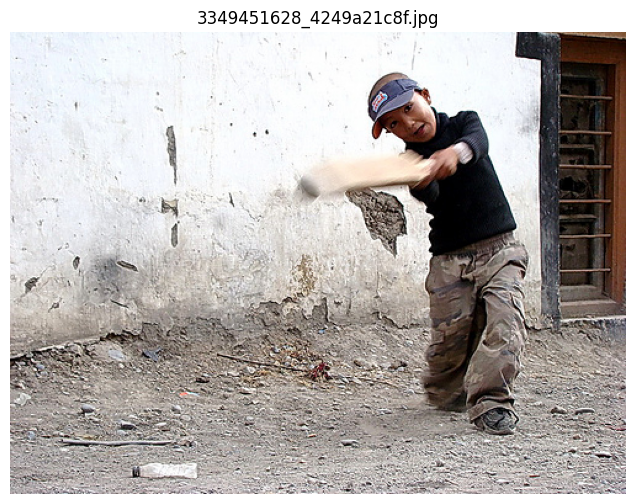

Generated Caption:
a man is playing with a red and white dog on a rock

Reference Captions:
1. A boy in a dusty alley playing stickball .
2. A boy swings a piece of wood .
3. A child swings a bat next to a stone wall .
4. A young boy wearing a blue visor swings a bat .
5. A young boy with a visor on plays ball with his bat in the street .



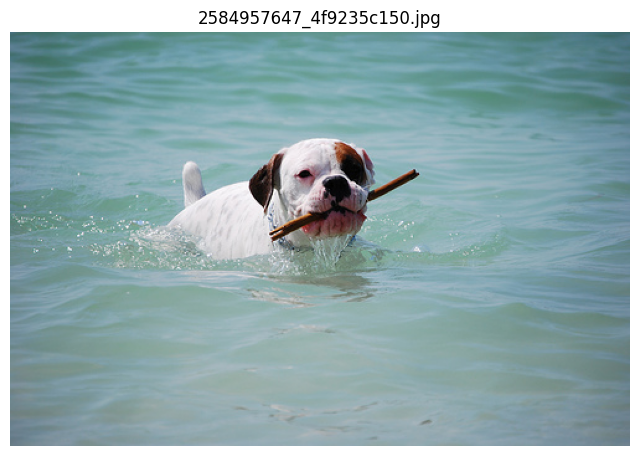

Generated Caption:
a white dog is running through the water

Reference Captions:
1. A dog is wading through deep water while holding a stick .
2. A white and brown dog is carrying a stick in the water .
3. A white dog with a brown spot over one eye in a pool of blue water with a stick in its mouth .
4. A white dog with brown spots on his face with a stick in his mouth swimming in water .
5. The white dog brings a stick from the water .



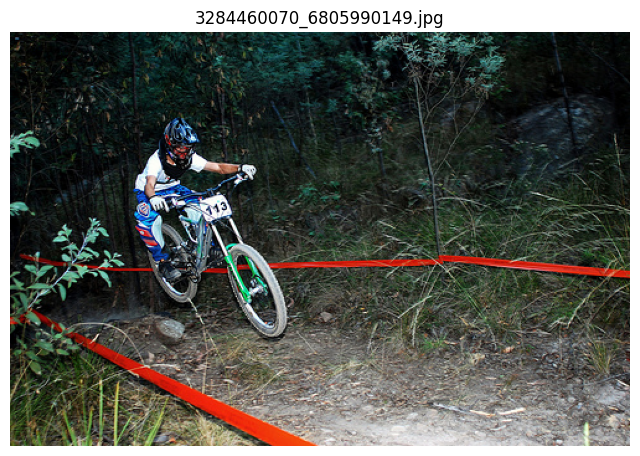

Generated Caption:
a man rides a bike through the woods

Reference Captions:
1. A biker going up a path lined with red tape .
2. a bmx rider takes air along the course .
3. A motocross rider does a jump in the woods .
4. Biker in colorful clothes riding a trail .
5. The mountain bike is being ridden on a trail through the wood that is marked out by red tape .



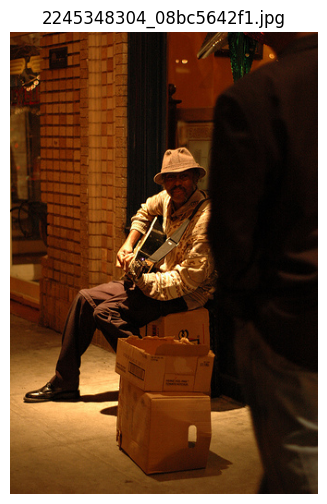

Generated Caption:
a man sits on a bench reading a book

Reference Captions:
1. A man in a hat sits outside near some cardboard boxes .
2. a man plays his guitar on the street .
3. A man sits on a box and plays a guitar in the street .
4. A man sits ourdoors next to cardboard boxes and plays an instrument .
5. An older musician perfoms on the street behind a cardboard box .



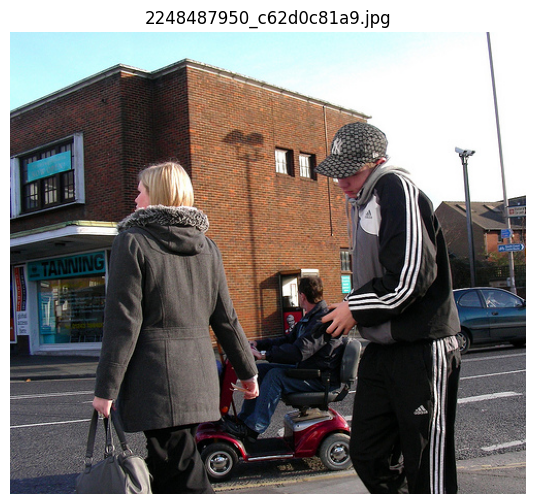

Generated Caption:
two men on a bench

Reference Captions:
1. A man and a woman wait to cross a street .
2. a man talks on his cellphone and another man rides a wheelchair .
3. A woman crosses the street near a man , who is on his cellphone .
4. A woman in a coat and a man in a tracksuit talking on a phone cross the street .
5. A woman tries to cross the road before a man on a red scooter .



In [54]:
# ============================================
# 28. Test Caption Generation
# ============================================

import random
import matplotlib.pyplot as plt
from PIL import Image

sample_images = random.sample(
    list(test_df["image"].unique()),
    5
)

for image_name in sample_images:

    # Get image feature
    feature = loaded_features[image_name]

    # Generate caption
    generated_caption = generate_caption(
        model,
        feature,
        word2idx,
        idx2word,
        device,
        max_len=MAX_LEN
    )

    # Display image
    image_path = IMAGES_DIR / image_name
    image = Image.open(image_path)

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(image_name)
    plt.show()

    print("Generated Caption:")
    print(generated_caption)

    print("\nReference Captions:")

    references = test_df[
        test_df["image"] == image_name
    ]["caption"]

    for i, caption in enumerate(
        references,
        1
    ):
        print(f"{i}. {caption}")

    print("\n" + "=" * 80)

In [55]:
# ============================================
# 29. Evaluation Libraries
# ============================================

!pip install -q nltk rouge-score

import nltk

nltk.download("punkt", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

from nltk.translate.bleu_score import (
    corpus_bleu,
    SmoothingFunction
)

from nltk.translate.meteor_score import (
    meteor_score
)

from rouge_score import rouge_scorer

print("Evaluation libraries ready!")

  Preparing metadata (setup.py) ... done
Evaluation libraries ready!


In [56]:
# ============================================
# 30. Prepare Test References
# ============================================

test_images = test_df["image"].unique()

print("Number of test images:", len(test_images))

test_references = {}

for image_name in test_images:

    references = test_df[
        test_df["image"] == image_name
    ]["caption"].tolist()

    test_references[image_name] = references

print(
    "References for first image:",
    len(test_references[test_images[0]])
)

Number of test images: 810
References for first image: 5


In [57]:
# ============================================
# 31. Generate Captions for Test Set
# ============================================

generated_captions = {}

print("Generating captions...\n")

for i, image_name in enumerate(test_images):

    # Get cached ResNet feature
    feature = loaded_features[image_name]

    # Generate caption
    caption = generate_caption(
        model,
        feature,
        word2idx,
        idx2word,
        device,
        max_len=MAX_LEN
    )

    generated_captions[image_name] = caption

    if (i + 1) % 100 == 0:
        print(
            f"Generated {i + 1}/{len(test_images)}"
        )

print("\nCaption generation completed!")
print(
    "Total generated captions:",
    len(generated_captions)
)

Generating captions...

Generated 100/810
Generated 200/810
Generated 300/810
Generated 400/810
Generated 500/810
Generated 600/810
Generated 700/810
Generated 800/810

Caption generation completed!
Total generated captions: 810


In [58]:
# ============================================
# 32. BLEU Evaluation
# ============================================

smoothie = SmoothingFunction().method4

references_bleu = []
hypotheses_bleu = []

for image_name in test_images:

    refs = test_references[image_name]

    generated = generated_captions[image_name]

    # Tokenize references
    refs_tokens = [
        ref.lower().split()
        for ref in refs
    ]

    # Tokenize generated caption
    generated_tokens = (
        generated.lower().split()
    )

    references_bleu.append(
        refs_tokens
    )

    hypotheses_bleu.append(
        generated_tokens
    )

# BLEU-1
bleu1 = corpus_bleu(
    references_bleu,
    hypotheses_bleu,
    weights=(1, 0, 0, 0),
    smoothing_function=smoothie
)

# BLEU-2
bleu2 = corpus_bleu(
    references_bleu,
    hypotheses_bleu,
    weights=(0.5, 0.5, 0, 0),
    smoothing_function=smoothie
)

# BLEU-3
bleu3 = corpus_bleu(
    references_bleu,
    hypotheses_bleu,
    weights=(1/3, 1/3, 1/3, 0),
    smoothing_function=smoothie
)

# BLEU-4
bleu4 = corpus_bleu(
    references_bleu,
    hypotheses_bleu,
    weights=(0.25, 0.25, 0.25, 0.25),
    smoothing_function=smoothie
)

print("=" * 50)
print("BLEU RESULTS")
print("=" * 50)

print(f"BLEU-1: {bleu1:.4f}")
print(f"BLEU-2: {bleu2:.4f}")
print(f"BLEU-3: {bleu3:.4f}")
print(f"BLEU-4: {bleu4:.4f}")

BLEU RESULTS
BLEU-1: 0.5862
BLEU-2: 0.4071
BLEU-3: 0.2710
BLEU-4: 0.1798


In [59]:
# ============================================
# 33. ROUGE-L Evaluation
# ============================================

rouge = rouge_scorer.RougeScorer(
    ["rougeL"],
    use_stemmer=True
)

rouge_scores = []

for image_name in test_images:

    generated = generated_captions[
        image_name
    ]

    references = test_references[
        image_name
    ]

    reference_scores = []

    for reference in references:

        score = rouge.score(
            reference,
            generated
        )

        reference_scores.append(
            score["rougeL"].fmeasure
        )

    # Best matching reference
    best_score = max(
        reference_scores
    )

    rouge_scores.append(
        best_score
    )

rouge_l = sum(
    rouge_scores
) / len(rouge_scores)

print(
    f"ROUGE-L: {rouge_l:.4f}"
)

ROUGE-L: 0.4562


In [60]:
# ============================================
# 34. METEOR Evaluation
# ============================================

meteor_scores = []

for image_name in test_images:

    generated = generated_captions[
        image_name
    ]

    references = test_references[
        image_name
    ]

    generated_tokens = (
        generated.lower().split()
    )

    reference_scores = []

    for reference in references:

        reference_tokens = (
            reference.lower().split()
        )

        score = meteor_score(
            [reference_tokens],
            generated_tokens
        )

        reference_scores.append(score)

    # Best reference
    best_score = max(
        reference_scores
    )

    meteor_scores.append(
        best_score
    )

meteor = sum(
    meteor_scores
) / len(meteor_scores)

print(
    f"METEOR: {meteor:.4f}"
)

METEOR: 0.3687


In [61]:
# ============================================
# 35. Final Evaluation Results
# ============================================

evaluation_results = {
    "BLEU-1": bleu1,
    "BLEU-2": bleu2,
    "BLEU-3": bleu3,
    "BLEU-4": bleu4,
    "ROUGE-L": rouge_l,
    "METEOR": meteor
}

print("\n" + "=" * 60)
print("FINAL TEST SET RESULTS")
print("=" * 60)

for metric, score in evaluation_results.items():

    print(
        f"{metric:<10}: {score:.4f}"
    )

print("=" * 60)


FINAL TEST SET RESULTS
BLEU-1    : 0.5862
BLEU-2    : 0.4071
BLEU-3    : 0.2710
BLEU-4    : 0.1798
ROUGE-L   : 0.4562
METEOR    : 0.3687


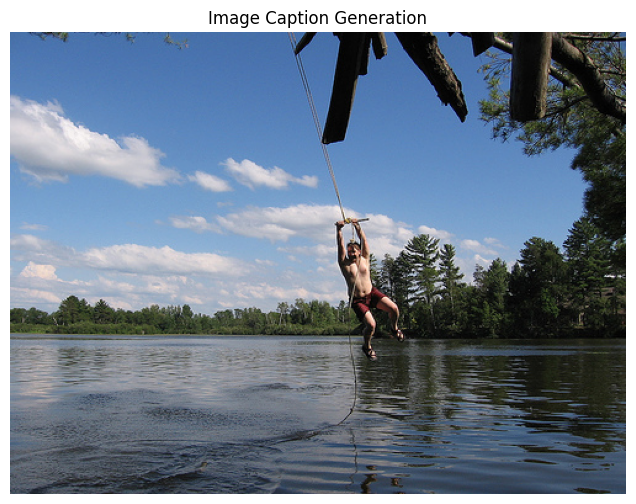

Generated Caption:
a person is jumping off a dock into the water

Reference Captions:
1. A man in a maroon bathing suit swings on a rope on a lake .
2. A man in red shorts swinging on a rope over a lake .
3. A man is swinging on a rope above the water .
4. A man is swinging on a rope over water .
5. This man is swinging on the rope swing out over the blue water .



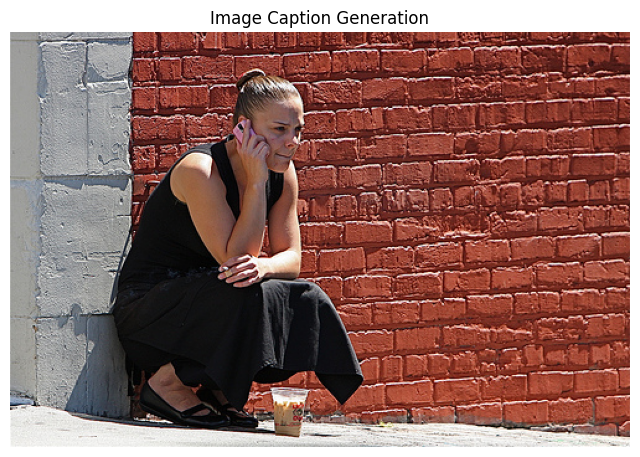

Generated Caption:
a man sits on a bench with a white and black purse

Reference Captions:
1. A woman in a black dress crouching in front of a brick wall talking on a cellphone .
2. A woman in all black crouches against a wall while making a phone call .
3. A woman on the phone next to a brick wall .
4. The woman crouches against a brick wall , speaking on her cellphone .
5. Woman talking on pink cellphone in front of a brick wall .



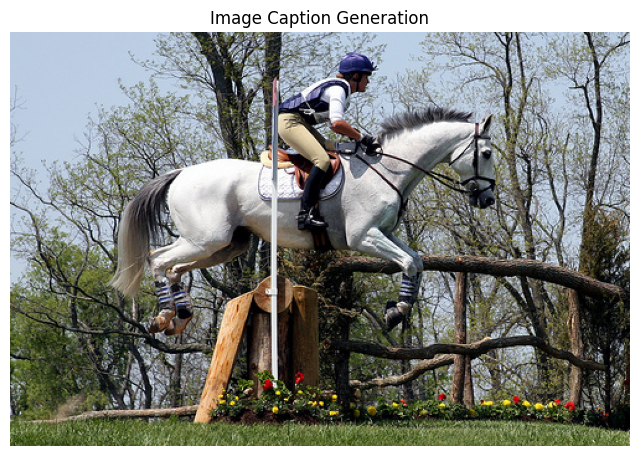

Generated Caption:
a person on a horse jumping over a hurdle

Reference Captions:
1. An equestrian and horse make a jump on a course .
2. A rider on a white horse is in the middle of a jump over a hurdle .
3. A show jumper wearing a blue helmet rides a white horse over wooden fence that is decorated with red and yellow flowers .
4. The rider is practicing jumps on a beautiful white horse .
5. White horse with jockey jumps a barrier



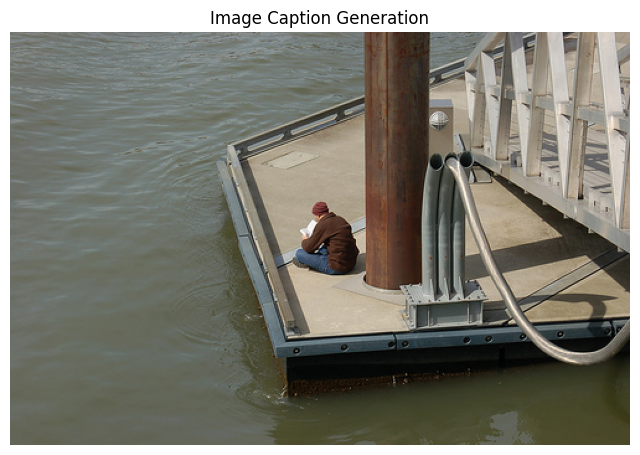

Generated Caption:
a man in a boat is paddling a boat

Reference Captions:
1. A man in a brown shirt sitting on a dock and reading .
2. A man is sitting next to the water , reading .
3. A man reading a book on the dock near a post .
4. A person in a brown jacket is sitting on a pier by the water reading .
5. Person sitting on concrete landing next to body of water



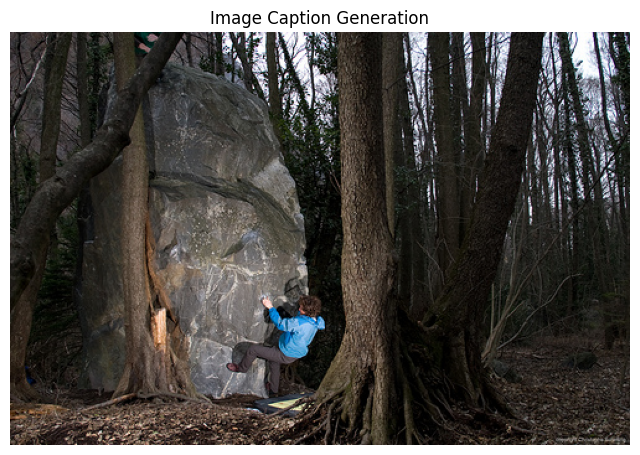

Generated Caption:
a person is climbing a rock face

Reference Captions:
1. A man in a blue jacket is climbing on a rock in the woods .
2. A person in a blue jacket climbs a large rock in a dark forest .
3. A person is climbing a rock in a forest .
4. A rock climber in the forest .
5. A woman in blue is climbing up a big rock .



In [62]:
# ============================================
# 36. Qualitative Evaluation
# ============================================

import random
import matplotlib.pyplot as plt
from PIL import Image

qualitative_images = random.sample(
    list(test_images),
    5
)

for image_name in qualitative_images:

    # ----------------------------------------
    # Load image
    # ----------------------------------------

    image_path = IMAGES_DIR / image_name
    image = Image.open(image_path)

    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title("Image Caption Generation")
    plt.show()

    # ----------------------------------------
    # Generated caption
    # ----------------------------------------

    print("Generated Caption:")
    print(
        generated_captions[image_name]
    )

    # ----------------------------------------
    # Reference captions
    # ----------------------------------------

    print("\nReference Captions:")

    for i, reference in enumerate(
        test_references[image_name],
        1
    ):

        print(
            f"{i}. {reference}"
        )

    print("\n" + "=" * 80)

Limitations: The model can correctly identify general activities and scene context, but it may occasionally generate incorrect object attributes, relationships, or repetitive phrases. These errors are expected in a relatively lightweight LSTM-based image captioning architecture trained on a limited dataset.

In [63]:
# ============================================
# 37. Save Production Model Artifacts
# ============================================

from pathlib import Path
import pickle
import json
import shutil
import torch

# --------------------------------------------
# Production directory
# --------------------------------------------

PRODUCTION_DIR = Path(
    "/content/drive/MyDrive/Flickr8k_Production"
)

PRODUCTION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Production directory:")
print(PRODUCTION_DIR)

# --------------------------------------------
# 1. Copy best model
# --------------------------------------------

MODEL_PATH = PRODUCTION_DIR / "best_caption_model.pth"

shutil.copy2(
    BEST_MODEL_PATH,
    MODEL_PATH
)

print("\n✓ Model copied")

# --------------------------------------------
# 2. Save vocabulary
# --------------------------------------------

VOCAB_PATH = PRODUCTION_DIR / "vocabulary.pkl"

with open(
    VOCAB_PATH,
    "wb"
) as f:

    pickle.dump(
        {
            "word2idx": word2idx,
            "idx2word": idx2word
        },
        f
    )

print("✓ Vocabulary saved")

# --------------------------------------------
# 3. Save configuration
# --------------------------------------------

config = {
    "vocab_size": len(word2idx),
    "max_len": int(MAX_LEN),
    "pad_idx": int(PAD_IDX),
    "start_idx": int(word2idx["<start>"]),
    "end_idx": int(word2idx["<end>"]),
    "feature_dim": 2048,
    "architecture": "ResNet-50 + LSTM",
    "dataset": "Flickr8k"
}

CONFIG_PATH = PRODUCTION_DIR / "config.json"

with open(
    CONFIG_PATH,
    "w"
) as f:

    json.dump(
        config,
        f,
        indent=4
    )

print("✓ Configuration saved")

# --------------------------------------------
# 4. Save evaluation results
# --------------------------------------------

RESULTS_PATH = PRODUCTION_DIR / "evaluation_results.json"

with open(
    RESULTS_PATH,
    "w"
) as f:

    json.dump(
        {
            k: float(v)
            for k, v in evaluation_results.items()
        },
        f,
        indent=4
    )

print("✓ Evaluation results saved")

# --------------------------------------------
# Summary
# --------------------------------------------

print("\n" + "=" * 60)
print("PRODUCTION ARTIFACTS")
print("=" * 60)

for file in PRODUCTION_DIR.iterdir():

    print(
        f"{file.name:<35} "
        f"{file.stat().st_size / (1024**2):.2f} MB"
    )

print("=" * 60)

Production directory:
/content/drive/MyDrive/Flickr8k_Production

✓ Model copied
✓ Vocabulary saved
✓ Configuration saved
✓ Evaluation results saved

PRODUCTION ARTIFACTS
best_caption_model.pth              85.14 MB
vocabulary.pkl                      0.09 MB
config.json                         0.00 MB
evaluation_results.json             0.00 MB


In [68]:
# ============================================
# 38. Save ResNet-50 Feature Extractor
# ============================================

RESNET_PATH = PRODUCTION_DIR / "resnet50.pth"

torch.save(
    resnet.state_dict(),
    RESNET_PATH
)

print("✓ ResNet-50 saved")
print(
    f"File size: "
    f"{RESNET_PATH.stat().st_size / (1024**2):.2f} MB"
)

✓ ResNet-50 saved
File size: 97.79 MB


In [69]:
# ============================================
# 39. Verify Production Artifacts
# ============================================

required_files = [
    "best_caption_model.pth",
    "vocabulary.pkl",
    "config.json",
    "evaluation_results.json",
    "resnet50.pth"
]

print("=" * 60)
print("VERIFYING PRODUCTION ARTIFACTS")
print("=" * 60)

all_exist = True

for filename in required_files:

    path = PRODUCTION_DIR / filename

    exists = path.exists()

    print(
        f"{'✓' if exists else '✗'} {filename}"
    )

    if not exists:
        all_exist = False

print("=" * 60)

if all_exist:
    print("✓ ALL PRODUCTION ARTIFACTS ARE READY!")
else:
    print("⚠ Some artifacts are missing!")

VERIFYING PRODUCTION ARTIFACTS
✓ best_caption_model.pth
✓ vocabulary.pkl
✓ config.json
✓ evaluation_results.json
✓ resnet50.pth
✓ ALL PRODUCTION ARTIFACTS ARE READY!
